# KNN

## Importar Dados

In [16]:
import pandas as pd
caminho = '../'

X_test = pd.read_csv(caminho + 'database/processed/splitted/X_test.csv')
X_train = pd.read_csv(caminho + 'database/processed/splitted/X_train.csv')
y_test = pd.read_csv(caminho + 'database/processed/splitted/y_test.csv')
y_train = pd.read_csv(caminho + 'database/processed/splitted/y_train.csv')

## KNN - Default

In [17]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

c:\Users\renan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


=== MÉTRICAS DE DESEMPENHO (KNN DEFAULT) ===

Acurácia: 0.7748
Precisão: 0.7432
Recall: 0.7467
F1-Score: 0.7449
MCC: 0.4899
AUC: 0.7998
--------------------------------------------------


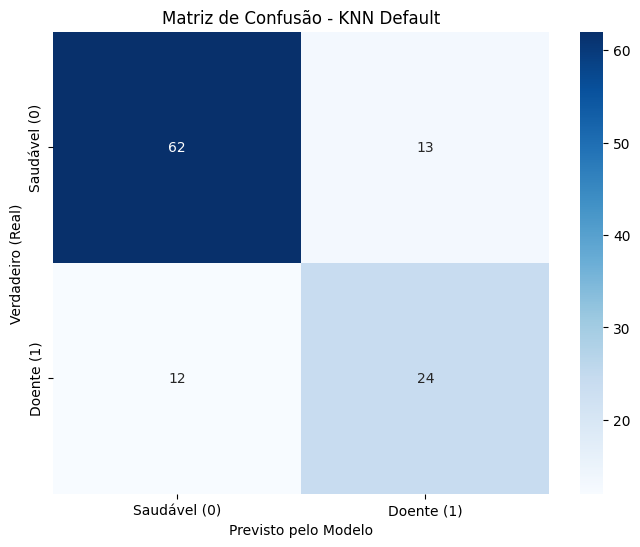

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             matthews_corrcoef, confusion_matrix)

# Fazendo as Previsões no conjunto de teste
y_pred_def = knn.predict(X_test)
y_prob_def = knn.predict_proba(X_test)[:, 1]

# Métricas
acuracia_def = accuracy_score(y_test, y_pred_def)
precisao_def = precision_score(y_test, y_pred_def, average='macro', zero_division=0)
recall_def = recall_score(y_test, y_pred_def, average='macro', zero_division=0)
f1_def = f1_score(y_test, y_pred_def, average='macro', zero_division=0)
mcc_def = matthews_corrcoef(y_test, y_pred_def)
auc = roc_auc_score(y_test, y_prob_def)

# Exibindo os Resultados
print("=== MÉTRICAS DE DESEMPENHO (KNN DEFAULT) ===\n")
print(f"Acurácia: {acuracia_def:.4f}")
print(f"Precisão: {precisao_def:.4f}")
print(f"Recall: {recall_def:.4f}")
print(f"F1-Score: {f1_def:.4f}")
print(f"MCC: {mcc_def:.4f}")
print(f"AUC: {auc:.4f}")
print("-" * 50)

# Plotando a Matriz de Confusão
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_def)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Saudável (0)', 'Doente (1)'],
            yticklabels=['Saudável (0)', 'Doente (1)'])
plt.title('Matriz de Confusão - KNN Default')
plt.xlabel('Previsto pelo Modelo')
plt.ylabel('Verdadeiro (Real)')
plt.show()

## KNN - Melhorado

In [19]:
import optuna
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 1, 30),
        'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
        'p': trial.suggest_int('p', 1, 10)
    }

    clf = KNeighborsClassifier(**params, n_jobs=-1)

    # Validação cruzada com F1-macro para avaliar o desempenho
    score = cross_val_score(clf, X_train, y_train.values.ravel(), scoring='accuracy', cv=5, n_jobs=-1).mean()
    return score

# Criando e executando o estudo
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"Melhor pontuação (CV): {study.best_value:.4f}")
print("Melhores parâmetros:")
print(study.best_params)

# Treinando o modelo final com os melhores parâmetros encontrados
best_knn = KNeighborsClassifier(**study.best_params, n_jobs=-1)
best_knn.fit(X_train, y_train.values.ravel())

[I 2026-08-16 11:29:52,156] A new study created in memory with name: no-name-8bcabd30-b3ec-41cf-a44d-794cc29c4185
Best trial: 1. Best value: 0.771192:   1%|          | 1/100 [00:00<00:06, 14.22it/s]

[I 2026-08-16 11:29:52,199] Trial 0 finished with value: 0.7710407239819005 and parameters: {'n_neighbors': 22, 'weights': 'distance', 'p': 8}. Best is trial 0 with value: 0.7710407239819005.
[I 2026-08-16 11:29:52,225] Trial 1 finished with value: 0.7711915535444946 and parameters: {'n_neighbors': 29, 'weights': 'uniform', 'p': 7}. Best is trial 1 with value: 0.7711915535444946.


Best trial: 3. Best value: 0.794646:   4%|▍         | 4/100 [00:00<00:04, 23.10it/s]

[I 2026-08-16 11:29:52,290] Trial 2 finished with value: 0.7750377073906486 and parameters: {'n_neighbors': 17, 'weights': 'uniform', 'p': 5}. Best is trial 2 with value: 0.7750377073906486.
[I 2026-08-16 11:29:52,331] Trial 3 finished with value: 0.7946455505279034 and parameters: {'n_neighbors': 11, 'weights': 'uniform', 'p': 3}. Best is trial 3 with value: 0.7946455505279034.
[I 2026-08-16 11:29:52,372] Trial 4 finished with value: 0.7673453996983408 and parameters: {'n_neighbors': 26, 'weights': 'uniform', 'p': 6}. Best is trial 3 with value: 0.7946455505279034.


Best trial: 3. Best value: 0.794646:   6%|▌         | 6/100 [00:00<00:03, 24.94it/s]

[I 2026-08-16 11:29:52,399] Trial 5 finished with value: 0.7405731523378581 and parameters: {'n_neighbors': 1, 'weights': 'distance', 'p': 1}. Best is trial 3 with value: 0.7946455505279034.
[I 2026-08-16 11:29:52,439] Trial 6 finished with value: 0.7597285067873303 and parameters: {'n_neighbors': 1, 'weights': 'distance', 'p': 4}. Best is trial 3 with value: 0.7946455505279034.


Best trial: 8. Best value: 0.810106:   9%|▉         | 9/100 [00:00<00:03, 25.61it/s]

[I 2026-08-16 11:29:52,482] Trial 7 finished with value: 0.7789592760180996 and parameters: {'n_neighbors': 23, 'weights': 'uniform', 'p': 10}. Best is trial 3 with value: 0.7946455505279034.
[I 2026-08-16 11:29:52,510] Trial 8 finished with value: 0.810105580693816 and parameters: {'n_neighbors': 12, 'weights': 'distance', 'p': 6}. Best is trial 8 with value: 0.810105580693816.
[I 2026-08-16 11:29:52,556] Trial 9 finished with value: 0.7597285067873303 and parameters: {'n_neighbors': 1, 'weights': 'distance', 'p': 4}. Best is trial 8 with value: 0.810105580693816.


Best trial: 8. Best value: 0.810106:  12%|█▏        | 12/100 [00:00<00:03, 25.13it/s]

[I 2026-08-16 11:29:52,589] Trial 10 finished with value: 0.7984917043740574 and parameters: {'n_neighbors': 10, 'weights': 'distance', 'p': 9}. Best is trial 8 with value: 0.810105580693816.
[I 2026-08-16 11:29:52,633] Trial 11 finished with value: 0.810105580693816 and parameters: {'n_neighbors': 9, 'weights': 'distance', 'p': 10}. Best is trial 8 with value: 0.810105580693816.


Best trial: 8. Best value: 0.810106:  15%|█▌        | 15/100 [00:00<00:03, 25.93it/s]

[I 2026-08-16 11:29:52,670] Trial 12 finished with value: 0.7830316742081447 and parameters: {'n_neighbors': 11, 'weights': 'distance', 'p': 10}. Best is trial 8 with value: 0.810105580693816.
[I 2026-08-16 11:29:52,710] Trial 13 finished with value: 0.7673453996983408 and parameters: {'n_neighbors': 7, 'weights': 'distance', 'p': 8}. Best is trial 8 with value: 0.810105580693816.
[I 2026-08-16 11:29:52,745] Trial 14 finished with value: 0.7716440422322776 and parameters: {'n_neighbors': 15, 'weights': 'distance', 'p': 1}. Best is trial 8 with value: 0.810105580693816.


Best trial: 8. Best value: 0.810106:  16%|█▌        | 16/100 [00:00<00:03, 25.93it/s]

[I 2026-08-16 11:29:52,777] Trial 15 finished with value: 0.771417797888386 and parameters: {'n_neighbors': 6, 'weights': 'distance', 'p': 6}. Best is trial 8 with value: 0.810105580693816.
[I 2026-08-16 11:29:52,819] Trial 16 finished with value: 0.7984162895927602 and parameters: {'n_neighbors': 16, 'weights': 'distance', 'p': 8}. Best is trial 8 with value: 0.810105580693816.


Best trial: 17. Best value: 0.814253:  18%|█▊        | 18/100 [00:00<00:03, 24.91it/s]

[I 2026-08-16 11:29:52,871] Trial 17 finished with value: 0.8142533936651585 and parameters: {'n_neighbors': 6, 'weights': 'distance', 'p': 2}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:52,928] Trial 18 finished with value: 0.8063348416289593 and parameters: {'n_neighbors': 5, 'weights': 'distance', 'p': 2}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253:  21%|██        | 21/100 [00:00<00:03, 22.27it/s]

[I 2026-08-16 11:29:52,984] Trial 19 finished with value: 0.8025641025641026 and parameters: {'n_neighbors': 14, 'weights': 'distance', 'p': 3}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:53,037] Trial 20 finished with value: 0.7904977375565612 and parameters: {'n_neighbors': 20, 'weights': 'distance', 'p': 5}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253:  22%|██▏       | 22/100 [00:00<00:03, 22.27it/s]

[I 2026-08-16 11:29:53,090] Trial 21 finished with value: 0.7907239819004526 and parameters: {'n_neighbors': 8, 'weights': 'distance', 'p': 7}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:53,136] Trial 22 finished with value: 0.7637254901960784 and parameters: {'n_neighbors': 4, 'weights': 'distance', 'p': 3}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253:  25%|██▌       | 25/100 [00:01<00:03, 21.64it/s]

[I 2026-08-16 11:29:53,183] Trial 23 finished with value: 0.814027149321267 and parameters: {'n_neighbors': 9, 'weights': 'distance', 'p': 9}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:53,237] Trial 24 finished with value: 0.7828808446455506 and parameters: {'n_neighbors': 14, 'weights': 'distance', 'p': 7}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:53,275] Trial 25 finished with value: 0.7676470588235295 and parameters: {'n_neighbors': 4, 'weights': 'distance', 'p': 9}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253:  27%|██▋       | 27/100 [00:01<00:03, 21.79it/s]

[I 2026-08-16 11:29:53,319] Trial 26 finished with value: 0.7984162895927602 and parameters: {'n_neighbors': 12, 'weights': 'uniform', 'p': 4}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:53,354] Trial 27 finished with value: 0.8024886877828055 and parameters: {'n_neighbors': 18, 'weights': 'distance', 'p': 2}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253:  30%|███       | 30/100 [00:01<00:03, 23.26it/s]

[I 2026-08-16 11:29:53,384] Trial 28 finished with value: 0.7868024132730014 and parameters: {'n_neighbors': 13, 'weights': 'distance', 'p': 6}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:53,427] Trial 29 finished with value: 0.7907993966817497 and parameters: {'n_neighbors': 8, 'weights': 'distance', 'p': 9}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:53,480] Trial 30 finished with value: 0.7368778280542987 and parameters: {'n_neighbors': 3, 'weights': 'distance', 'p': 5}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253:  32%|███▏      | 32/100 [00:01<00:02, 23.26it/s]

[I 2026-08-16 11:29:53,512] Trial 31 finished with value: 0.810105580693816 and parameters: {'n_neighbors': 9, 'weights': 'distance', 'p': 10}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:53,556] Trial 32 finished with value: 0.814027149321267 and parameters: {'n_neighbors': 9, 'weights': 'distance', 'p': 9}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253:  36%|███▌      | 36/100 [00:01<00:02, 23.11it/s]

[I 2026-08-16 11:29:53,627] Trial 33 finished with value: 0.7675716440422322 and parameters: {'n_neighbors': 6, 'weights': 'distance', 'p': 8}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:53,660] Trial 34 finished with value: 0.7907993966817497 and parameters: {'n_neighbors': 11, 'weights': 'uniform', 'p': 8}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:53,691] Trial 35 finished with value: 0.7673453996983408 and parameters: {'n_neighbors': 7, 'weights': 'uniform', 'p': 9}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253:  38%|███▊      | 38/100 [00:01<00:02, 23.11it/s]

[I 2026-08-16 11:29:53,723] Trial 36 finished with value: 0.7750377073906486 and parameters: {'n_neighbors': 30, 'weights': 'distance', 'p': 7}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:53,764] Trial 37 finished with value: 0.8062594268476622 and parameters: {'n_neighbors': 12, 'weights': 'distance', 'p': 7}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:53,806] Trial 38 finished with value: 0.7986425339366516 and parameters: {'n_neighbors': 19, 'weights': 'uniform', 'p': 2}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253:  39%|███▉      | 39/100 [00:01<00:02, 23.93it/s]

[I 2026-08-16 11:29:53,869] Trial 39 finished with value: 0.7984162895927602 and parameters: {'n_neighbors': 10, 'weights': 'distance', 'p': 6}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253:  42%|████▏     | 42/100 [00:01<00:02, 21.82it/s]

[I 2026-08-16 11:29:53,921] Trial 40 finished with value: 0.7368778280542987 and parameters: {'n_neighbors': 3, 'weights': 'uniform', 'p': 5}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:53,966] Trial 41 finished with value: 0.810105580693816 and parameters: {'n_neighbors': 9, 'weights': 'distance', 'p': 10}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:54,023] Trial 42 finished with value: 0.814027149321267 and parameters: {'n_neighbors': 9, 'weights': 'distance', 'p': 9}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253:  43%|████▎     | 43/100 [00:01<00:02, 21.82it/s]

[I 2026-08-16 11:29:54,070] Trial 43 finished with value: 0.7751885369532427 and parameters: {'n_neighbors': 13, 'weights': 'distance', 'p': 9}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253:  46%|████▌     | 46/100 [00:02<00:02, 21.09it/s]

[I 2026-08-16 11:29:54,124] Trial 44 finished with value: 0.7673453996983408 and parameters: {'n_neighbors': 7, 'weights': 'distance', 'p': 8}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:54,172] Trial 45 finished with value: 0.7984917043740574 and parameters: {'n_neighbors': 10, 'weights': 'distance', 'p': 9}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:54,210] Trial 46 finished with value: 0.7750377073906486 and parameters: {'n_neighbors': 24, 'weights': 'distance', 'p': 8}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253:  48%|████▊     | 48/100 [00:02<00:02, 21.71it/s]

[I 2026-08-16 11:29:54,254] Trial 47 finished with value: 0.7867269984917045 and parameters: {'n_neighbors': 16, 'weights': 'distance', 'p': 10}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:54,306] Trial 48 finished with value: 0.794947209653092 and parameters: {'n_neighbors': 5, 'weights': 'distance', 'p': 1}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253:  51%|█████     | 51/100 [00:02<00:02, 21.58it/s]

[I 2026-08-16 11:29:54,339] Trial 49 finished with value: 0.8139517345399698 and parameters: {'n_neighbors': 12, 'weights': 'distance', 'p': 4}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:54,393] Trial 50 finished with value: 0.7637254901960784 and parameters: {'n_neighbors': 8, 'weights': 'distance', 'p': 4}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:54,432] Trial 51 finished with value: 0.8023378582202112 and parameters: {'n_neighbors': 10, 'weights': 'distance', 'p': 4}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253:  54%|█████▍    | 54/100 [00:02<00:02, 22.12it/s]

[I 2026-08-16 11:29:54,474] Trial 52 finished with value: 0.7907993966817497 and parameters: {'n_neighbors': 12, 'weights': 'distance', 'p': 9}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:54,522] Trial 53 finished with value: 0.8025641025641026 and parameters: {'n_neighbors': 14, 'weights': 'distance', 'p': 3}. Best is trial 17 with value: 0.8142533936651585.


[I 2026-08-16 11:29:54,572] Trial 54 finished with value: 0.7984917043740574 and parameters: {'n_neighbors': 11, 'weights': 'distance', 'p': 3}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:54,605] Trial 55 finished with value: 0.7947963800904977 and parameters: {'n_neighbors': 9, 'weights': 'distance', 'p': 1}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253:  58%|█████▊    | 58/100 [00:02<00:01, 22.43it/s]

[I 2026-08-16 11:29:54,653] Trial 56 finished with value: 0.7675716440422322 and parameters: {'n_neighbors': 6, 'weights': 'distance', 'p': 8}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:54,685] Trial 57 finished with value: 0.8064102564102565 and parameters: {'n_neighbors': 15, 'weights': 'distance', 'p': 2}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:54,735] Trial 58 finished with value: 0.798265460030166 and parameters: {'n_neighbors': 13, 'weights': 'uniform', 'p': 4}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253:  60%|██████    | 60/100 [00:02<00:01, 23.50it/s]

[I 2026-08-16 11:29:54,766] Trial 59 finished with value: 0.7635746606334841 and parameters: {'n_neighbors': 2, 'weights': 'distance', 'p': 10}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:54,797] Trial 60 finished with value: 0.7791101055806939 and parameters: {'n_neighbors': 8, 'weights': 'distance', 'p': 5}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253:  63%|██████▎   | 63/100 [00:02<00:01, 24.14it/s]

[I 2026-08-16 11:29:54,849] Trial 61 finished with value: 0.810105580693816 and parameters: {'n_neighbors': 9, 'weights': 'distance', 'p': 10}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:54,880] Trial 62 finished with value: 0.7793363499245852 and parameters: {'n_neighbors': 6, 'weights': 'distance', 'p': 9}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:54,931] Trial 63 finished with value: 0.7907993966817495 and parameters: {'n_neighbors': 11, 'weights': 'distance', 'p': 9}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253:  66%|██████▌   | 66/100 [00:02<00:01, 24.06it/s]

[I 2026-08-16 11:29:54,962] Trial 64 finished with value: 0.7867269984917045 and parameters: {'n_neighbors': 7, 'weights': 'distance', 'p': 10}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:55,003] Trial 65 finished with value: 0.7561085972850679 and parameters: {'n_neighbors': 5, 'weights': 'distance', 'p': 7}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253:  67%|██████▋   | 67/100 [00:02<00:01, 24.06it/s]

[I 2026-08-16 11:29:55,054] Trial 66 finished with value: 0.7907993966817497 and parameters: {'n_neighbors': 12, 'weights': 'distance', 'p': 9}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:55,109] Trial 67 finished with value: 0.7673453996983408 and parameters: {'n_neighbors': 27, 'weights': 'distance', 'p': 10}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253:  69%|██████▉   | 69/100 [00:03<00:01, 22.18it/s]

[I 2026-08-16 11:29:55,161] Trial 68 finished with value: 0.779185520361991 and parameters: {'n_neighbors': 9, 'weights': 'distance', 'p': 2}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:55,215] Trial 69 finished with value: 0.7674962292609351 and parameters: {'n_neighbors': 10, 'weights': 'uniform', 'p': 8}. Best is trial 17 with value: 0.8142533936651585.


[I 2026-08-16 11:29:55,250] Trial 70 finished with value: 0.7868024132730016 and parameters: {'n_neighbors': 8, 'weights': 'distance', 'p': 6}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:55,283] Trial 71 finished with value: 0.810105580693816 and parameters: {'n_neighbors': 9, 'weights': 'distance', 'p': 10}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253:  75%|███████▌  | 75/100 [00:03<00:01, 22.93it/s]

[I 2026-08-16 11:29:55,340] Trial 72 finished with value: 0.7830316742081447 and parameters: {'n_neighbors': 11, 'weights': 'distance', 'p': 10}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:55,373] Trial 73 finished with value: 0.7793363499245852 and parameters: {'n_neighbors': 6, 'weights': 'distance', 'p': 9}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:55,420] Trial 74 finished with value: 0.7790346907993966 and parameters: {'n_neighbors': 13, 'weights': 'distance', 'p': 10}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253:  76%|███████▌  | 76/100 [00:03<00:01, 22.93it/s]

[I 2026-08-16 11:29:55,452] Trial 75 finished with value: 0.7673453996983408 and parameters: {'n_neighbors': 7, 'weights': 'distance', 'p': 9}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:55,484] Trial 76 finished with value: 0.7676470588235295 and parameters: {'n_neighbors': 4, 'weights': 'distance', 'p': 10}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253:  79%|███████▉  | 79/100 [00:03<00:00, 24.09it/s]

[I 2026-08-16 11:29:55,533] Trial 77 finished with value: 0.7984917043740574 and parameters: {'n_neighbors': 12, 'weights': 'distance', 'p': 8}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:55,566] Trial 78 finished with value: 0.7828808446455506 and parameters: {'n_neighbors': 14, 'weights': 'distance', 'p': 6}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:55,621] Trial 79 finished with value: 0.767420814479638 and parameters: {'n_neighbors': 10, 'weights': 'uniform', 'p': 9}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253:  81%|████████  | 81/100 [00:03<00:00, 23.55it/s]

[I 2026-08-16 11:29:55,662] Trial 80 finished with value: 0.7830316742081449 and parameters: {'n_neighbors': 8, 'weights': 'distance', 'p': 10}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:55,696] Trial 81 finished with value: 0.810105580693816 and parameters: {'n_neighbors': 9, 'weights': 'distance', 'p': 10}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253:  85%|████████▌ | 85/100 [00:03<00:00, 25.35it/s]

[I 2026-08-16 11:29:55,731] Trial 82 finished with value: 0.806184012066365 and parameters: {'n_neighbors': 10, 'weights': 'distance', 'p': 10}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:55,762] Trial 83 finished with value: 0.7673453996983408 and parameters: {'n_neighbors': 7, 'weights': 'distance', 'p': 9}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:55,800] Trial 84 finished with value: 0.814027149321267 and parameters: {'n_neighbors': 9, 'weights': 'distance', 'p': 9}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:55,833] Trial 85 finished with value: 0.7907993966817497 and parameters: {'n_neighbors': 11, 'weights': 'distance', 'p': 8}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253:  88%|████████▊ | 88/100 [00:03<00:00, 25.89it/s]

[I 2026-08-16 11:29:55,865] Trial 86 finished with value: 0.7907993966817497 and parameters: {'n_neighbors': 8, 'weights': 'distance', 'p': 9}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:55,908] Trial 87 finished with value: 0.7944193061840121 and parameters: {'n_neighbors': 17, 'weights': 'distance', 'p': 8}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253:  89%|████████▉ | 89/100 [00:03<00:00, 25.89it/s]

[I 2026-08-16 11:29:55,963] Trial 88 finished with value: 0.7600301659125188 and parameters: {'n_neighbors': 5, 'weights': 'distance', 'p': 4}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:56,014] Trial 89 finished with value: 0.806184012066365 and parameters: {'n_neighbors': 12, 'weights': 'distance', 'p': 5}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253:  92%|█████████▏| 92/100 [00:03<00:00, 24.22it/s]

[I 2026-08-16 11:29:56,053] Trial 90 finished with value: 0.8062594268476622 and parameters: {'n_neighbors': 9, 'weights': 'distance', 'p': 7}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:56,089] Trial 91 finished with value: 0.814027149321267 and parameters: {'n_neighbors': 9, 'weights': 'distance', 'p': 9}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:56,142] Trial 92 finished with value: 0.7907993966817495 and parameters: {'n_neighbors': 11, 'weights': 'distance', 'p': 9}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253:  94%|█████████▍| 94/100 [00:04<00:00, 23.82it/s]

[I 2026-08-16 11:29:56,186] Trial 93 finished with value: 0.7984917043740574 and parameters: {'n_neighbors': 10, 'weights': 'distance', 'p': 9}. Best is trial 17 with value: 0.8142533936651585.


[I 2026-08-16 11:29:56,233] Trial 94 finished with value: 0.7673453996983408 and parameters: {'n_neighbors': 7, 'weights': 'distance', 'p': 9}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:56,283] Trial 95 finished with value: 0.7907239819004526 and parameters: {'n_neighbors': 8, 'weights': 'distance', 'p': 7}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:56,326] Trial 96 finished with value: 0.7947963800904977 and parameters: {'n_neighbors': 21, 'weights': 'distance', 'p': 2}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253:  97%|█████████▋| 97/100 [00:04<00:00, 23.01it/s]

[I 2026-08-16 11:29:56,371] Trial 97 finished with value: 0.7948717948717948 and parameters: {'n_neighbors': 13, 'weights': 'uniform', 'p': 3}. Best is trial 17 with value: 0.8142533936651585.


Best trial: 17. Best value: 0.814253: 100%|██████████| 100/100 [00:04<00:00, 23.21it/s]

[I 2026-08-16 11:29:56,419] Trial 98 finished with value: 0.7907993966817497 and parameters: {'n_neighbors': 11, 'weights': 'distance', 'p': 8}. Best is trial 17 with value: 0.8142533936651585.
[I 2026-08-16 11:29:56,459] Trial 99 finished with value: 0.7947963800904977 and parameters: {'n_neighbors': 9, 'weights': 'distance', 'p': 1}. Best is trial 17 with value: 0.8142533936651585.
Melhor pontuação (CV): 0.8143
Melhores parâmetros:
{'n_neighbors': 6, 'weights': 'distance', 'p': 2}


,n_neighbors,6
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,-1


In [20]:
fig = optuna.visualization.plot_param_importances(study)
fig.show()

fig = optuna.visualization.plot_optimization_history(study)
fig.show()

=== MÉTRICAS DE DESEMPENHO ===

Acurácia: 0.7477
Precisão: 0.7114
Recall:   0.7050
F1-Score: 0.7079
MCC:      0.4164
AUC:      0.8237
--------------------------------------------------


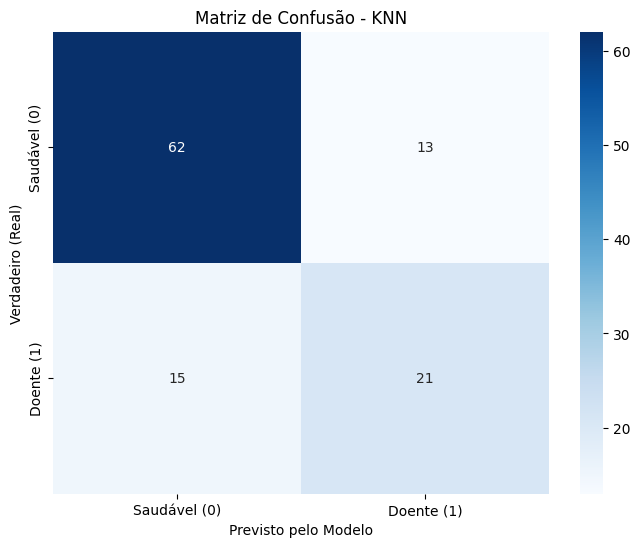

In [21]:
# Fazendo as Previsões
y_pred_best = best_knn.predict(X_test)
y_prob_best = best_knn.predict_proba(X_test)[:, 1]

# Métricas
acuracia_best = accuracy_score(y_test, y_pred_best)
precisao_best = precision_score(y_test, y_pred_best, average='macro')
recall_best   = recall_score(y_test, y_pred_best, average='macro')
f1_best       = f1_score(y_test, y_pred_best, average='macro')
mcc_best      = matthews_corrcoef(y_test, y_pred_best)

# O AUC binário recebe as classes reais e as probabilidades diretamente
auc = roc_auc_score(y_test, y_prob_best)

# Exibindo os Resultados
print("=== MÉTRICAS DE DESEMPENHO ===\n")
print(f"Acurácia: {acuracia_best:.4f}")
print(f"Precisão: {precisao_best:.4f}")
print(f"Recall:   {recall_best:.4f}")
print(f"F1-Score: {f1_best:.4f}")
print(f"MCC:      {mcc_best:.4f}")
print(f"AUC:      {auc:.4f}")
print("-" * 50)


# 5. Plotando a Matriz de Confusão
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)

# Labels ajustados exclusivamente para as duas doenças
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Saudável (0)', 'Doente (1)'],
            yticklabels=['Saudável (0)', 'Doente (1)'])

plt.title('Matriz de Confusão - KNN')
plt.xlabel('Previsto pelo Modelo')
plt.ylabel('Verdadeiro (Real)')
plt.show()

## Salvar Resultados

In [22]:
import os
import pandas as pd

nome_modelo = 'knn'

# Caminhos dos arquivos
pasta_results = os.path.join(caminho, 'results')
os.makedirs(pasta_results, exist_ok=True)

arquivo_pred = os.path.join(pasta_results, 'predicoes.csv')
arquivo_proba = os.path.join(pasta_results, 'probabilidades.csv')

# Monta a linha com as predições de teste
linha_pred_teste = [nome_modelo, 'teste'] + list(y_pred_best)

# Salva adicionando no final do arquivo (mode='a')
pd.DataFrame([linha_pred_teste]).to_csv(
    arquivo_pred, mode='a', header=False, index=False
)

# Monta a linha com as probabilidades de teste 
probs = (
    y_prob_best[:, 1]
    if hasattr(y_prob_best, 'ndim') and y_prob_best.ndim == 2
    else y_prob_best
)
linha_proba_teste = [nome_modelo, 'teste'] + list(probs)

pd.DataFrame([linha_proba_teste]).to_csv(
    arquivo_proba, mode='a', header=False, index=False
)

print(f'Predições e probabilidades do modelo {nome_modelo} salvas com sucesso!')

Predições e probabilidades do modelo knn salvas com sucesso!
